In [33]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import os
from detect_wildlife_crossings.modelling.visualization import (
    plot_detection_subset,
    get_idx,
)

In [28]:
inference_export = "../model/runs/cassda-wildlife-crossing/yolo11-CH-conf0_35/detection_results_filtered_road_intersect.csv"
img_dir = "E:/cassda-data/street-tiles/CH/images"

### Display diff to CH

In [14]:
df_filtered = pd.read_csv(f"{inference_export}", header=0)
detections = df_filtered.to_dict(orient="records")

gdf_filtered = gpd.GeoDataFrame(
    df_filtered,
    geometry=gpd.points_from_xy(df_filtered.xc_epsg3035, df_filtered.yc_epsg3035),
    crs="EPSG:3035",
)

In [16]:
gt_gdf = gpd.read_file(
    "../data/geodata/ch_wildlifeoverpass_points.gdb",
    layer="N2023_Version_Wildtierpassagen",
)
gt_gdf = gt_gdf.to_crs(epsg=3035)
gt_gdf = gt_gdf[gt_gdf["Realisierungsjahr"] <= 2021]

In [18]:
roads_gdf = gpd.read_file("../data/geodata/CH_highway_depth_1.gpkg")

In [19]:
max_distance = 100

# calculate distance matrix
distance_matrix = gpd.GeoSeries(gt_gdf.geometry).apply(
    lambda geom: roads_gdf.geometry.distance(geom)
)
to_keep = []
for i in range(len(distance_matrix)):
    min_distance_to_road = distance_matrix.iloc[i, :].min()
    if min_distance_to_road <= max_distance:
        to_keep.append(i)

gt_gdf = gt_gdf.iloc[to_keep]

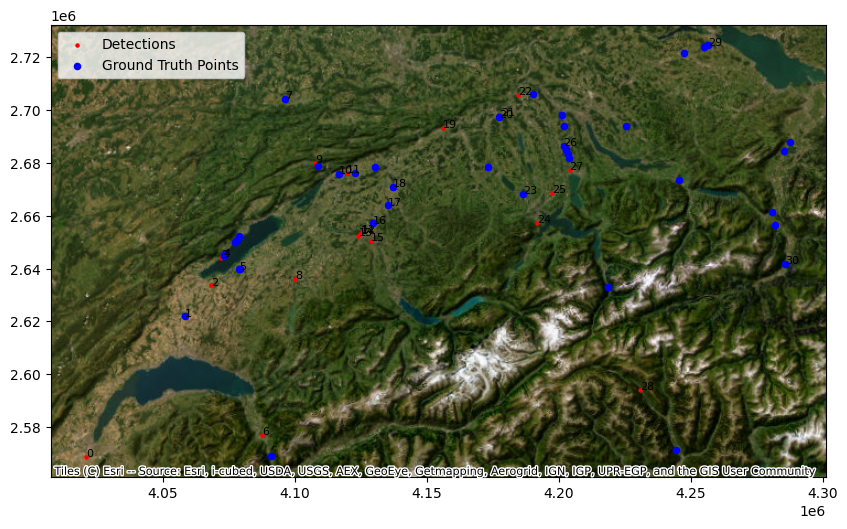

In [30]:
# plot detections and ground truth points
fig, ax = plt.subplots(figsize=(10, 10))
gdf_filtered.plot(ax=ax, color="red", markersize=5, label="Detections")
gt_gdf.plot(ax=ax, color="blue", markersize=20, label="Ground Truth Points")
# add labels to the detections
for x, y, label in zip(
    gdf_filtered.geometry.x,
    gdf_filtered.geometry.y,
    gdf_filtered.index,
):
    ax.text(x, y, f"{label}", fontsize=8, color="black")
ax.legend()
ctx.add_basemap(
    ax=ax,
    crs=gdf_filtered.crs.to_string(),
    source=ctx.providers.Esri.WorldImagery,
)

In [44]:
detections = df_filtered.to_dict(orient="records")
subset = detections[24:29]

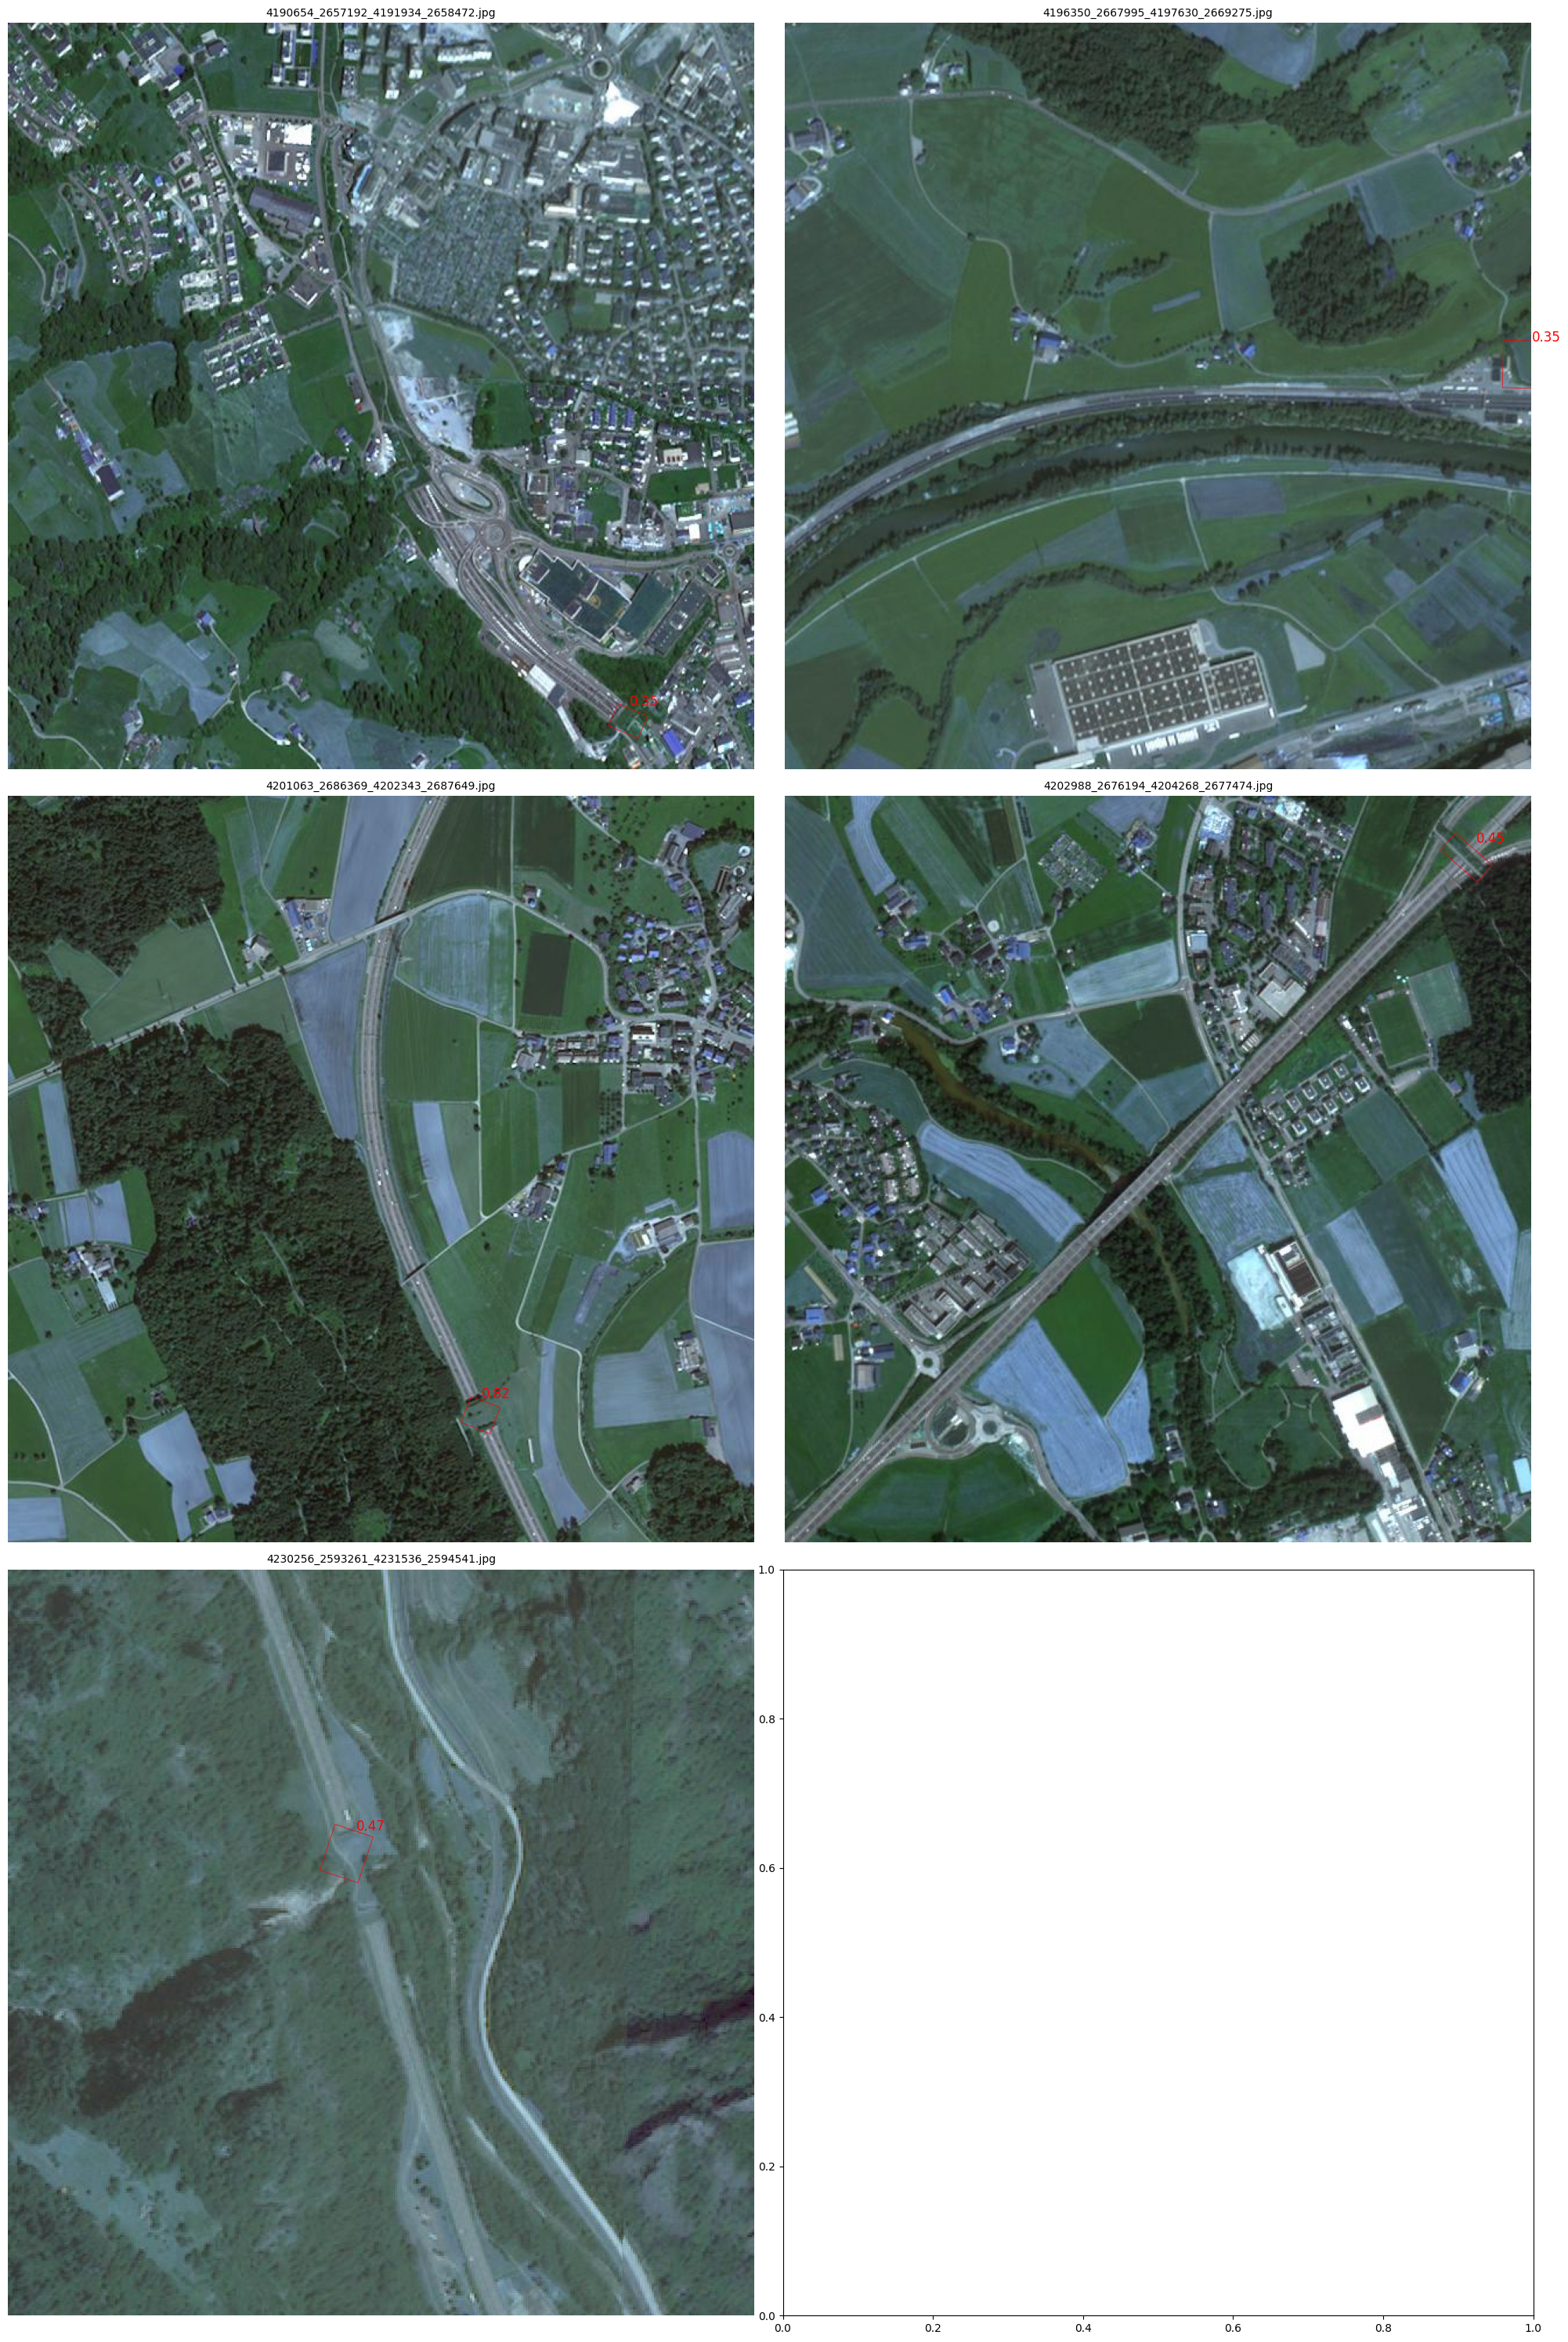

In [46]:
plot_detection_subset(subset, nrows=3, ncols=2, image_dir=img_dir)